/tmp/ipython-input-3463491636.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AADI.JK", start="2025-01-01", end="2026-01-31")
[*********************100%***********************]  1 of 1 completed

Fetching Data...
Calculating Features...


Running Hidden Markov Model...
Generating Chart...


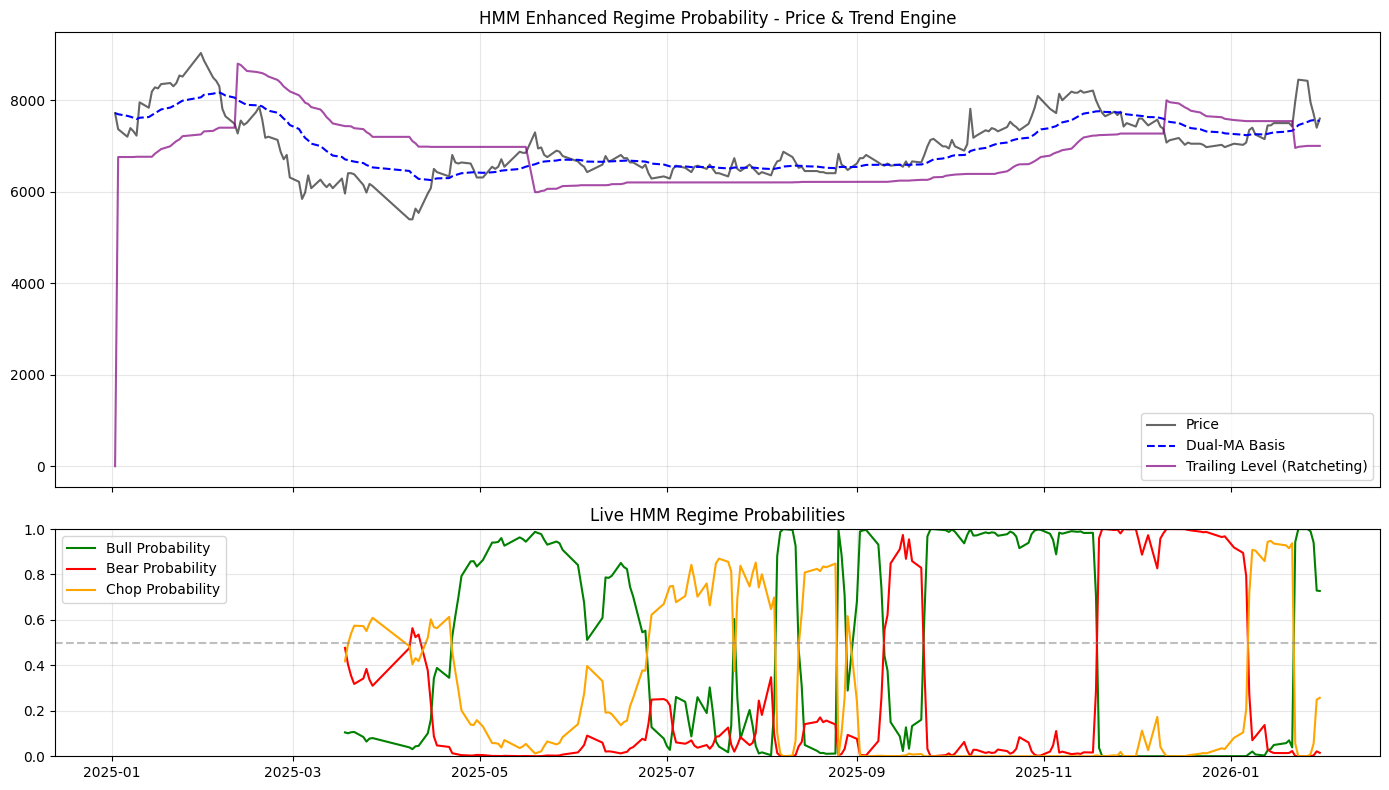

In [5]:
# 1. Install ONLY yfinance (Let Colab keep its default numpy/pandas/scipy)
!pip install -q yfinance

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.stats import norm

# ==========================================
# 1. FETCH DATA
# ==========================================
print("Fetching Data...")
df = yf.download("AADI.JK", start="2025-01-01", end="2026-01-31")
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel('Ticker') # Clean up yfinance output

# ==========================================
# 2. CUSTOM INDICATORS (Replacing pandas_ta)
# ==========================================
def rma(series, length):
    """TradingView's RMA (Wilder's Smoothing)"""
    return series.ewm(alpha=1/length, adjust=False).mean()

def calculate_atr(df, length=14):
    high_low = df['High'] - df['Low']
    high_close = np.abs(df['High'] - df['Close'].shift(1))
    low_close = np.abs(df['Low'] - df['Close'].shift(1))
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    return rma(tr, length)

def calculate_adx(df, length=14):
    up = df['High'] - df['High'].shift(1)
    down = df['Low'].shift(1) - df['Low']

    plus_dm = np.where((up > down) & (up > 0), up, 0.0)
    minus_dm = np.where((down > up) & (down > 0), down, 0.0)

    tr = pd.concat([df['High'] - df['Low'],
                    np.abs(df['High'] - df['Close'].shift(1)),
                    np.abs(df['Low'] - df['Close'].shift(1))], axis=1).max(axis=1)

    plus_di = 100 * rma(pd.Series(plus_dm, index=df.index), length) / rma(tr, length)
    minus_di = 100 * rma(pd.Series(minus_dm, index=df.index), length) / rma(tr, length)

    dx = 100 * np.abs(plus_di - minus_di) / (plus_di + minus_di)
    return rma(dx, length)

# ==========================================
# 3. ADAPTIVE TREND ENGINE & FEATURES
# ==========================================
print("Calculating Features...")
adaptive_len = 20
atr_len = 14
band_mult = 2.0
z_lookback = 50

# Calculate Dual-MA Basis
df['Fast_MA'] = df['Close'].ewm(span=adaptive_len, adjust=False).mean()
df['Slow_MA'] = df['Close'].ewm(span=adaptive_len * 2, adjust=False).mean()
df['Basis'] = (df['Fast_MA'] + df['Slow_MA']) / 2

# Calculate ATR and ADX
df['ATR'] = calculate_atr(df, atr_len)
df['Raw_F3'] = calculate_adx(df, 14) # ADX Line

# Calculate Ratcheting Trailing Level (Supertrend-style logic)
trailing_level = np.zeros(len(df))
trend_dir = np.ones(len(df)) # 1 for Bull, -1 for Bear

for i in range(1, len(df)):
    if pd.isna(df['Basis'].iloc[i]) or pd.isna(df['ATR'].iloc[i]):
        continue

    prev_dir = trend_dir[i-1]
    prev_level = trailing_level[i-1]
    curr_basis = df['Basis'].iloc[i]
    curr_band = df['ATR'].iloc[i] * band_mult
    close = df['Close'].iloc[i]

    if prev_dir == 1:
        new_level = curr_basis - curr_band
        new_level = max(new_level, prev_level) # Min/Max Ratchet (Up)
        if close < new_level: # Flip to bear
            trend_dir[i] = -1
            trailing_level[i] = curr_basis + curr_band
        else:
            trend_dir[i] = 1
            trailing_level[i] = new_level
    else:
        new_level = curr_basis + curr_band
        new_level = min(new_level, prev_level) if prev_level > 0 else new_level # Min/Max Ratchet (Down)
        if close > new_level: # Flip to bull
            trend_dir[i] = 1
            trailing_level[i] = curr_basis - curr_band
        else:
            trend_dir[i] = -1
            trailing_level[i] = new_level

df['Trailing_Level'] = trailing_level

# Raw Features
df['Raw_F1'] = (df['Close'] - df['Trailing_Level']) / df['ATR']
df['Raw_F2'] = df['Basis'].diff() / df['ATR']

# Z-Score Features (Rolling Window)
def rolling_zscore(series, window):
    return (series - series.rolling(window).mean()) / series.rolling(window).std()

df['F1'] = rolling_zscore(df['Raw_F1'], z_lookback)
df['F2'] = rolling_zscore(df['Raw_F2'], z_lookback)
df['F3'] = rolling_zscore(df['Raw_F3'], z_lookback)

# ==========================================
# 4. HMM ONLINE EM ALGORITHM
# ==========================================
print("Running Hidden Markov Model...")

T = np.array([
    [0.80, 0.04, 0.16], # From Bull
    [0.04, 0.80, 0.16], # From Bear
    [0.20, 0.20, 0.60]  # From Chop
])

means = np.array([
    [ 1.0,  0.7,  0.5], # Bull
    [-1.0, -0.7,  0.5], # Bear
    [ 0.0,  0.0, -0.5]  # Chop
])

stds = np.ones((3, 3))
min_std = 0.3
learning_rate = 0.05
temperature = 2.0

prior_prob = np.array([0.333, 0.333, 0.333])
posteriors = np.zeros((len(df), 3))

for i in range(len(df)):
    obs = np.array([df['F1'].iloc[i], df['F2'].iloc[i], df['F3'].iloc[i]])

    if np.isnan(obs).any():
        posteriors[i] = [np.nan, np.nan, np.nan]
        continue

    pred_prob = prior_prob @ T

    likelihoods = np.zeros(3)
    for s in range(3):
        p1 = norm.pdf(obs[0], means[s, 0], stds[s, 0])
        p2 = norm.pdf(obs[1], means[s, 1], stds[s, 1])
        p3 = norm.pdf(obs[2], means[s, 2], stds[s, 2])
        likelihoods[s] = p1 * p2 * p3

    likelihoods = likelihoods ** (1.0 / temperature)

    post = pred_prob * likelihoods
    if post.sum() == 0:
        post = np.array([0.333, 0.333, 0.333])
    else:
        post = post / post.sum()

    posteriors[i] = post

    dom_state = np.argmax(post)
    if post[dom_state] > 0.50:
        for f in range(3):
            means[dom_state, f] = (1 - learning_rate) * means[dom_state, f] + learning_rate * obs[f]
            var = stds[dom_state, f] ** 2
            var = (1 - learning_rate) * var + learning_rate * ((obs[f] - means[dom_state, f]) ** 2)
            stds[dom_state, f] = max(min_std, np.sqrt(var))

    prior_prob = post

df['Prob_Bull'] = posteriors[:, 0]
df['Prob_Bear'] = posteriors[:, 1]
df['Prob_Chop'] = posteriors[:, 2]

# ==========================================
# 5. PLOTTING RESULTS
# ==========================================
print("Generating Chart...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

ax1.plot(df.index, df['Close'], label='Price', color='black', alpha=0.6)
ax1.plot(df.index, df['Basis'], label='Dual-MA Basis', color='blue', linestyle='--')
ax1.plot(df.index, df['Trailing_Level'], label='Trailing Level (Ratcheting)', color='purple', alpha=0.7)
ax1.set_title("HMM Enhanced Regime Probability - Price & Trend Engine")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(df.index, df['Prob_Bull'], label='Bull Probability', color='green')
ax2.plot(df.index, df['Prob_Bear'], label='Bear Probability', color='red')
ax2.plot(df.index, df['Prob_Chop'], label='Chop Probability', color='orange')
ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax2.set_title("Live HMM Regime Probabilities")
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


══════════════════════════════════════════════
  HMM Enhanced: Regime Probability  (Python)
══════════════════════════════════════════════
  503 bars  (2024-02-20 → 2026-02-20)
  Building adaptive trend engine …
  Extracting z-scored features …
  Running Bayesian HMM forward pass …

╔══════════════════════════════════╗
║  REGIME     : BULLISH           ║
║  CONFIDENCE :  99.8%  HIGH       ║
║  P(BULL)    :  99.8%             ║
║  P(BEAR)    :   0.2%             ║
║  P(CHOP)    :   0.0%             ║
║  sig B/Br/C : 0.63/0.81/0.31  LRN ║
╚══════════════════════════════════╝

── Last 15 bars ──────────────────────────────────
                 Close P_Bull P_Bear P_Chop   Conf Regime
Date                                                     
2026-01-30  691.969971   4.4%  37.1%  58.5%  58.5%   CHOP
2026-02-02  695.409973   3.4%  30.8%  65.8%  65.8%   CHOP
2026-02-03  689.530029  18.7%  50.1%  31.2%  50.1%   BEAR
2026-02-04  686.190002  44.4%  54.4%   1.2%  54.4%   BEAR
2026-02-05  677.619

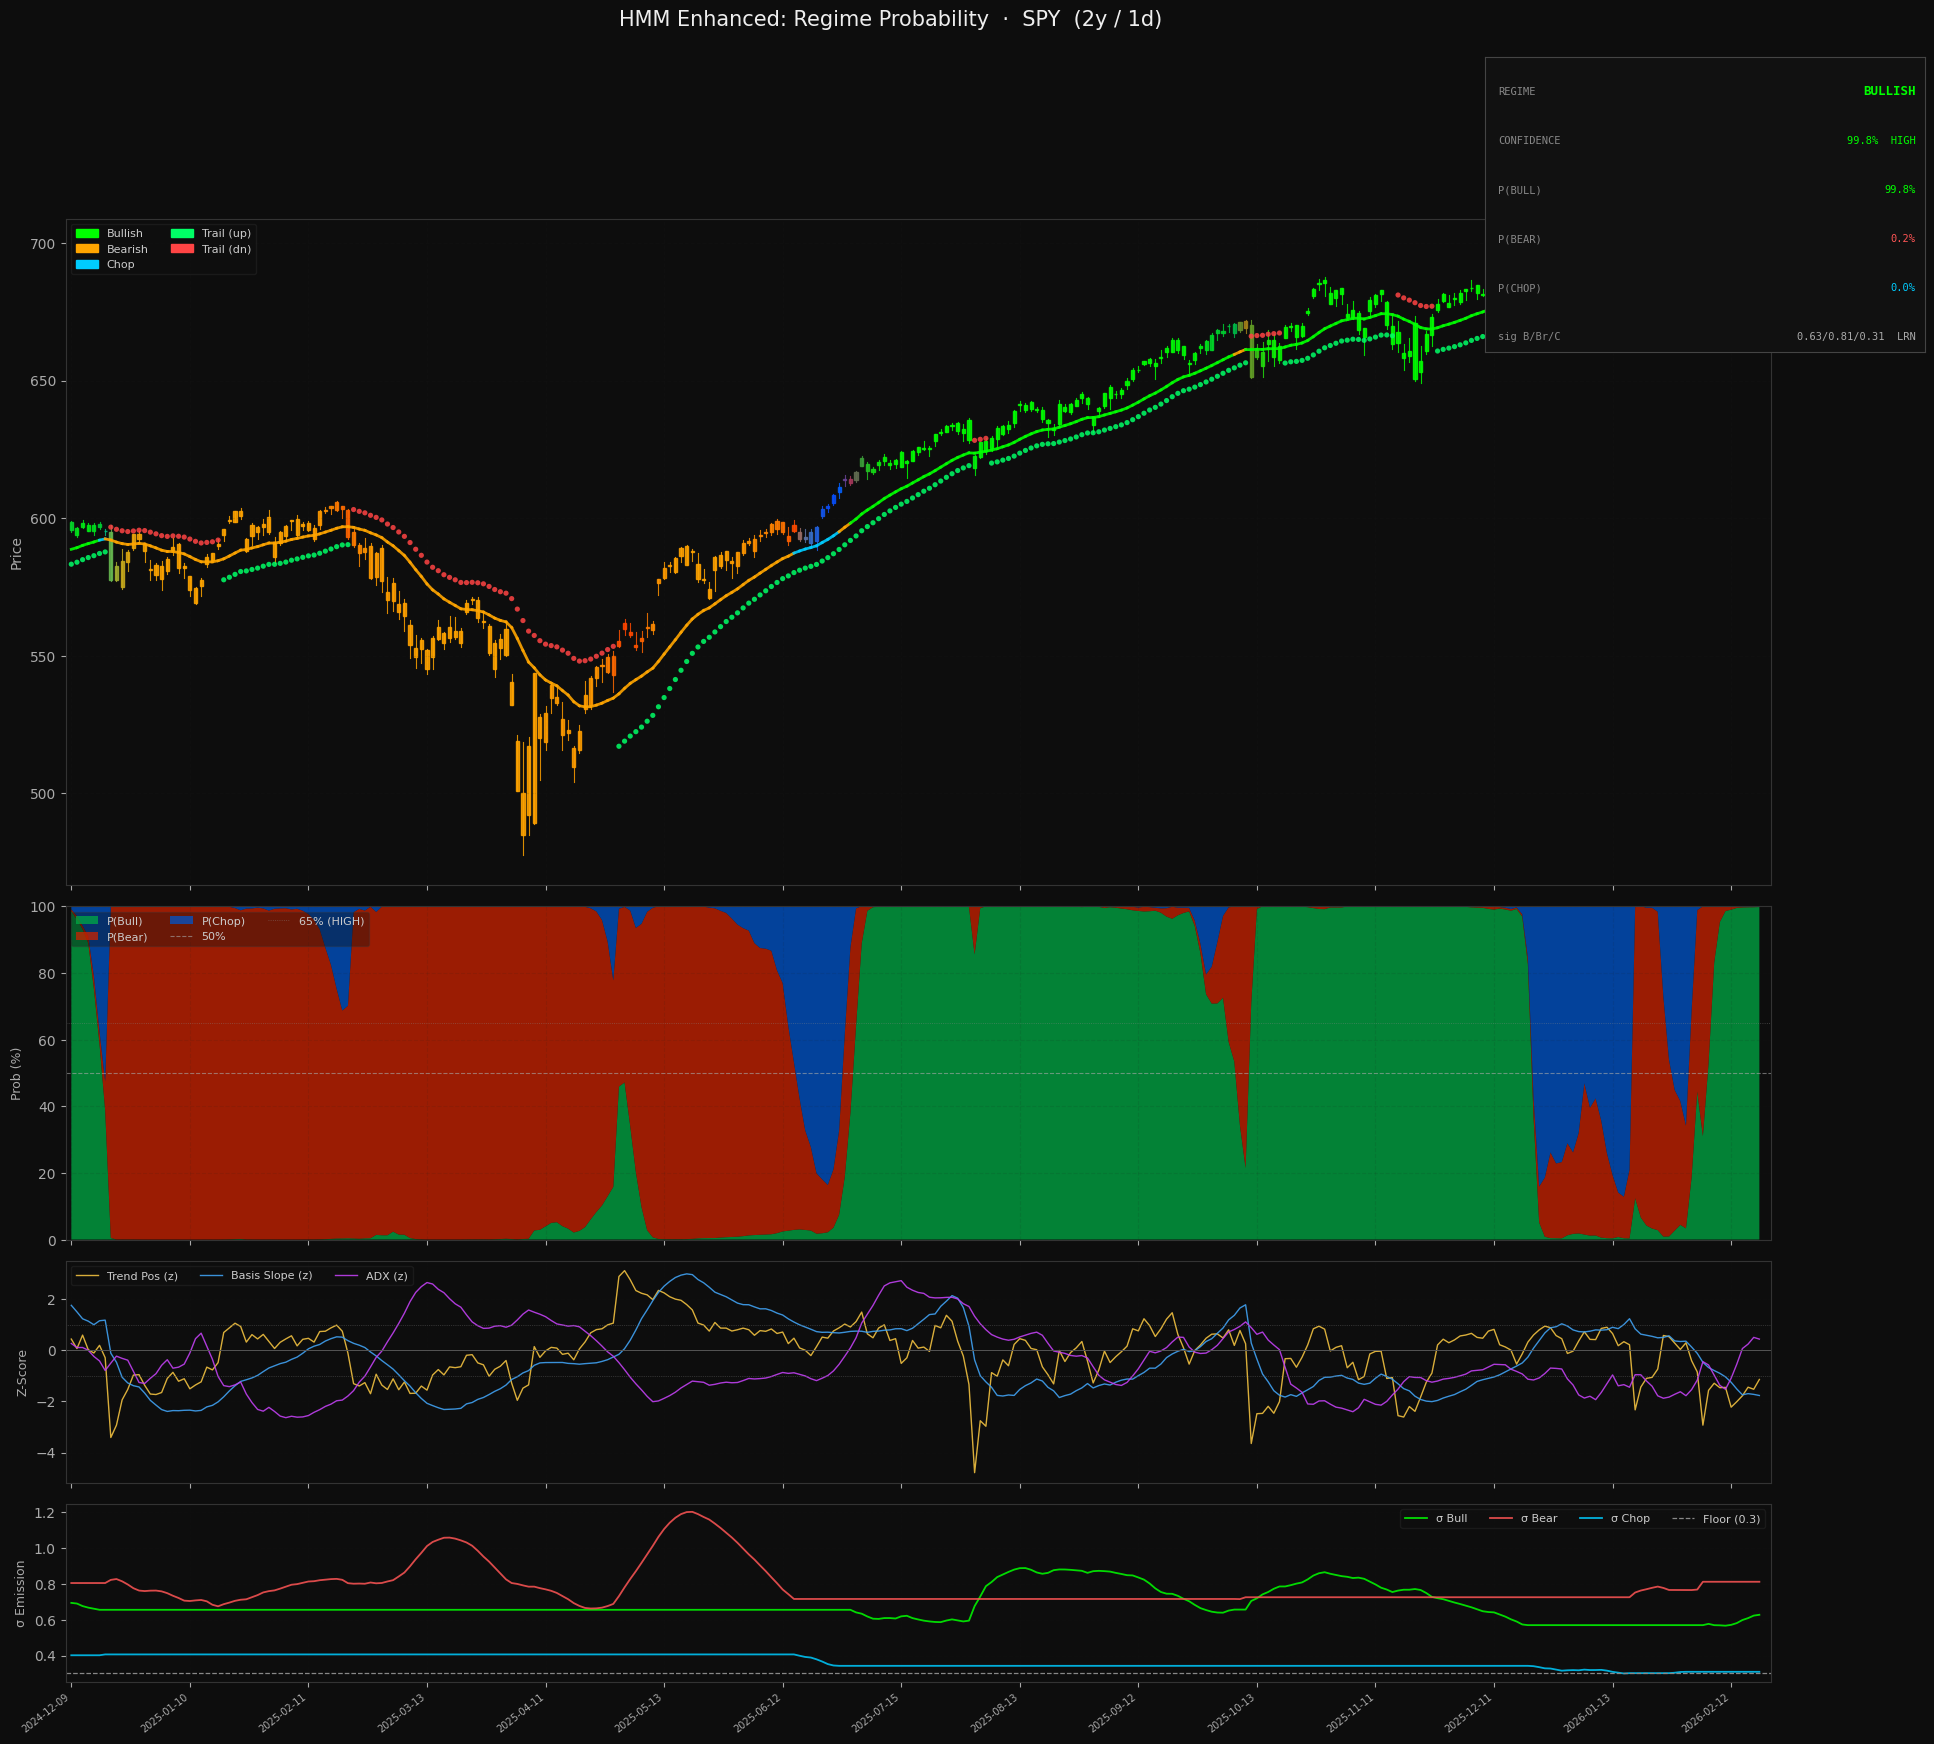

In [6]:
# ============================================================
#  HMM Enhanced: Regime Probability  –  Python / Colab Port
#  Original Pine Script by lucymatos (TradingView)
#  Python port – drop into a Google Colab cell or run locally
# ============================================================
#
#  QUICK START (Google Colab)
#  --------------------------
#  1. Paste this entire file into a Colab code cell and run it.
#     It will auto-install any missing packages and download
#     sample data from Yahoo Finance so you need no API key.
#
#  2. To use your own OHLCV data, replace the `load_data()`
#     call with a pandas DataFrame that has columns:
#         open, high, low, close, volume  (lowercase)
#     and a DatetimeIndex.
#
#  3. Tweak the CONFIG dict at the top to match the indicator
#     settings you'd use on TradingView.
# ============================================================

# ---------- auto-install missing packages ----------
import subprocess, sys

def _install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

for pkg in ["yfinance", "pandas", "numpy", "matplotlib"]:
    try:
        __import__(pkg.replace("-","_"))
    except ImportError:
        _install(pkg)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import yfinance as yf

plt.rcParams.update({
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor":   "#0d0d0d",
    "axes.edgecolor":   "#333333",
    "axes.labelcolor":  "#aaaaaa",
    "xtick.color":      "#aaaaaa",
    "ytick.color":      "#aaaaaa",
    "grid.color":       "#1e1e1e",
    "grid.linestyle":   "--",
    "text.color":       "#cccccc",
    "legend.facecolor": "#111111",
    "legend.edgecolor": "#333333",
})

# ============================================================
#  CONFIGURATION  (mirrors TradingView input panel)
# ============================================================
CONFIG = dict(
    # ── ticker / data ──────────────────────────────────────
    ticker      = "SPY",          # any yfinance symbol
    period      = "2y",           # yfinance period string  e.g. "1y","2y","5y"
    interval    = "1d",           # "1d","1wk","1h" etc.

    # ── 1. Adaptive Trend Engine ───────────────────────────
    source      = "hlc3",         # "close","hl2","hlc3","ohlc4"
    length      = 20,             # fast MA period; slow = 2x
    smoothing   = 20,             # ATR-band smoothing period
    multiplier  = 1.0,            # band width multiplier
    band_type   = "true_range",   # "atr","true_range","stdev"
    ma_type     = "wma",          # "ema","sma","wma","hma","rma","ssma"
    use_minmax  = False,          # ratchet trailing level

    # ── 2. ADX Settings ────────────────────────────────────
    adx_len     = 14,
    adx_smooth  = 14,
    zscore_len  = 50,

    # ── 3. Transition Matrix ───────────────────────────────
    p_stay_bull = 0.80,
    p_stay_bear = 0.80,
    p_stay_chop = 0.60,

    # ── 4. Adaptive Learning ───────────────────────────────
    use_learning = True,
    learn_rate   = 0.05,
    learn_floor  = 0.30,

    # ── 5. HMM ─────────────────────────────────────────────
    emission_temp = 2.0,          # > 1 softens confidence

    # ── 6. Visuals ─────────────────────────────────────────
    color_smooth = 0.4,
)

# ============================================================
#  MOVING AVERAGE HELPERS
# ============================================================

def _ema(s, n):
    return s.ewm(span=n, adjust=False).mean()

def _sma(s, n):
    return s.rolling(n).mean()

def _wma(s, n):
    w = np.arange(1, n + 1, dtype=float)
    return s.rolling(n).apply(lambda x: np.dot(x, w) / w.sum(), raw=True)

def _rma(s, n):
    return s.ewm(alpha=1/n, adjust=False).mean()

def _hma(s, n):
    half = max(1, n // 2)
    sqrt = max(1, int(round(n ** 0.5)))
    return _wma(2 * _wma(s, half) - _wma(s, n), sqrt)

def _ssma(s, n):
    """Ehlers Super Smoother"""
    a1 = np.exp(-np.sqrt(2) * np.pi / n)
    b1 = 2 * a1 * np.cos(np.sqrt(2) * np.pi / n)
    c3 = -a1 * a1
    c2 = b1
    c1 = 1 - c2 - c3
    arr = s.values.copy().astype(float)
    out = arr.copy()
    for i in range(2, len(arr)):
        out[i] = c1 * arr[i] + c2 * out[i-1] + c3 * out[i-2]
    return pd.Series(out, index=s.index)

def _ma(s, n, kind):
    fn = {"ema": _ema, "sma": _sma, "wma": _wma,
          "hma": _hma, "rma": _rma, "ssma": _ssma}
    return fn.get(kind, _wma)(s, n)

def _source(df, kind):
    if kind == "close":  return df["close"]
    if kind == "hl2":    return (df["high"] + df["low"]) / 2
    if kind == "hlc3":   return (df["high"] + df["low"] + df["close"]) / 3
    if kind == "ohlc4":  return (df["open"] + df["high"] + df["low"] + df["close"]) / 4
    return df["close"]

def _true_range(df):
    h, l, c = df["high"], df["low"], df["close"].shift(1)
    return pd.concat([h - l, (h - c).abs(), (l - c).abs()], axis=1).max(axis=1)

def _atr(df, n=14):
    return _rma(_true_range(df), n)

def _adx(df, dmi_len, smooth):
    """Wilder ADX / DI+ / DI-"""
    up   = df["high"].diff()
    down = -df["low"].diff()
    plus_dm  = np.where((up > down) & (up > 0), up, 0.0)
    minus_dm = np.where((down > up) & (down > 0), down, 0.0)
    plus_dm  = pd.Series(plus_dm,  index=df.index)
    minus_dm = pd.Series(minus_dm, index=df.index)
    atr_s    = _rma(_true_range(df), dmi_len)
    plus_di  = 100 * _rma(plus_dm,  dmi_len) / atr_s.replace(0, np.nan)
    minus_di = 100 * _rma(minus_dm, dmi_len) / atr_s.replace(0, np.nan)
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
    adx_line = _rma(dx.fillna(0), smooth)
    return plus_di, minus_di, adx_line

def _zscore(s, n):
    mu  = s.rolling(n).mean()
    sig = s.rolling(n).std()
    return ((s - mu) / sig.replace(0, np.nan)).fillna(0)

# ============================================================
#  GAUSSIAN PDF
# ============================================================

def gaussian_pdf(x, mu, sigma):
    sigma = max(sigma, 0.01)
    return (1.0 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# ============================================================
#  ADAPTIVE TREND ENGINE  (Crak-style dual-MA + ratchet trail)
# ============================================================

def adaptive_trend_engine(df, cfg):
    src   = _source(df, cfg["source"])
    n     = cfg["length"]
    sm    = cfg["smoothing"]
    multi = cfg["multiplier"]
    bt    = cfg["band_type"]
    mt    = cfg["ma_type"]
    ratch = cfg["use_minmax"]

    fast  = _ma(src, n, mt)
    slow  = _ma(src, n * 2, mt)
    basis = (fast + slow) / 2

    if bt == "true_range":
        vol = _sma(_true_range(df), sm)
    elif bt == "stdev":
        vol = src.rolling(n).std()
    else:
        vol = _atr(df, 14)

    vol_sm = _ma(vol, sm, mt)
    upper  = basis + vol_sm * multi
    lower  = basis - vol_sm * multi

    close_arr = df["close"].values
    basis_arr = basis.values
    upper_arr = upper.values
    lower_arr = lower.values
    N = len(close_arr)

    level = np.full(N, np.nan)
    trend = np.zeros(N, dtype=int)

    start = n * 2
    trend[start] = 1 if close_arr[start] > basis_arr[start] else -1
    level[start] = lower_arr[start] if trend[start] == 1 else upper_arr[start]

    for i in range(start + 1, N):
        t_prev = trend[i-1]
        l_prev = level[i-1]
        lo = lower_arr[i]
        hi = upper_arr[i]
        cl = close_arr[i]

        if np.isnan(l_prev):
            trend[i] = 1 if cl > basis_arr[i] else -1
            level[i] = lo if trend[i] == 1 else hi
            continue

        if t_prev == 1:
            if cl < l_prev:
                trend[i] = -1
                level[i] = hi
            else:
                level[i] = max(l_prev, lo) if ratch else lo
                trend[i] = 1
        else:
            if cl > l_prev:
                trend[i] = 1
                level[i] = lo
            else:
                level[i] = min(l_prev, hi) if ratch else hi
                trend[i] = -1

    basis_s = pd.Series(basis_arr, index=df.index)
    level_s = pd.Series(level,     index=df.index)
    trend_s = pd.Series(trend,     index=df.index)
    return basis_s, trend_s, level_s

# ============================================================
#  FEATURE EXTRACTION & Z-SCORING
# ============================================================

def build_features(df, basis, level, cfg):
    atr14 = _atr(df, 14).replace(0, np.nan)

    raw_tpos  = (df["close"] - level) / atr14
    raw_slope = (basis - basis.shift(cfg["length"])) / atr14
    _, _, adx_line = _adx(df, cfg["adx_len"], cfg["adx_smooth"])

    zl = cfg["zscore_len"]
    obs_tpos  = _zscore(raw_tpos,  zl)
    obs_slope = _zscore(raw_slope, zl)
    obs_adx   = _zscore(adx_line,  zl)

    return obs_tpos.fillna(0), obs_slope.fillna(0), obs_adx.fillna(0)

# ============================================================
#  BAYESIAN HMM FORWARD PASS  (bar-by-bar, causal, no lookahead)
# ============================================================

def run_hmm(df, obs_tpos, obs_slope, obs_adx, cfg):
    N = len(df)

    # Transition matrix  (row = from, col = to)
    pb  = cfg["p_stay_bull"];  sb  = 1 - pb
    pbr = cfg["p_stay_bear"];  sbr = 1 - pbr
    pc  = cfg["p_stay_chop"];  sc  = 1 - pc

    trans = np.array([
        # Bull->Bull   Bull->Bear   Bull->Chop
        [pb,           sb * 0.2,    sb * 0.8],
        # Bear->Bull   Bear->Bear   Bear->Chop
        [sbr * 0.2,    pbr,         sbr * 0.8],
        # Chop->Bull   Chop->Bear   Chop->Chop
        [sc * 0.5,     sc * 0.5,    pc],
    ])

    # Emission means  [tpos, slope, adx]  – same priors as Pine
    mu_bull = np.array([ 1.0,  0.7,  0.5])
    mu_bear = np.array([-1.0, -0.7,  0.5])
    mu_chop = np.array([ 0.0,  0.0, -0.5])
    sig     = np.array([ 1.0,  1.0,  1.0])   # [bull, bear, chop]

    lr   = cfg["learn_rate"]
    lf   = cfg["learn_floor"]
    temp = cfg["emission_temp"]

    p_bull_out = np.full(N, np.nan)
    p_bear_out = np.full(N, np.nan)
    p_chop_out = np.full(N, np.nan)
    sig_b_out  = np.full(N, np.nan)
    sig_br_out = np.full(N, np.nan)
    sig_c_out  = np.full(N, np.nan)

    prob = np.array([1/3, 1/3, 1/3])

    tp  = obs_tpos.values
    sl  = obs_slope.values
    adx = obs_adx.values

    for i in range(N):
        # prior
        prior = trans.T @ prob          # (3,)

        # emission likelihoods
        def emis(mu, sigma):
            return (gaussian_pdf(tp[i],  mu[0], sigma) *
                    gaussian_pdf(sl[i],  mu[1], sigma) *
                    gaussian_pdf(adx[i], mu[2], sigma))

        raw  = np.array([emis(mu_bull, sig[0]),
                         emis(mu_bear, sig[1]),
                         emis(mu_chop, sig[2])])
        raw  = np.maximum(raw, 1e-30)
        like = raw ** (1.0 / temp)

        # posterior
        post  = prior * like
        total = post.sum()
        if total > 0:
            prob = post / total

        p_bull_out[i] = prob[0]
        p_bear_out[i] = prob[1]
        p_chop_out[i] = prob[2]

        # online dominant-state EM
        if cfg["use_learning"]:
            obs_vec = np.array([tp[i], sl[i], adx[i]])

            if prob[0] > 0.5:
                mu_bull  += lr * (obs_vec - mu_bull)
                res       = np.abs(obs_vec - mu_bull).mean()
                sig[0]    = max(lf, sig[0] + lr * (res - sig[0]))

            if prob[1] > 0.5:
                mu_bear  += lr * (obs_vec - mu_bear)
                res       = np.abs(obs_vec - mu_bear).mean()
                sig[1]    = max(lf, sig[1] + lr * (res - sig[1]))

            if prob[2] > 0.5:
                mu_chop  += lr * (obs_vec - mu_chop)
                res       = np.abs(obs_vec - mu_chop).mean()
                sig[2]    = max(lf, sig[2] + lr * (res - sig[2]))

        sig_b_out[i]  = sig[0]
        sig_br_out[i] = sig[1]
        sig_c_out[i]  = sig[2]

    return (pd.Series(p_bull_out, index=df.index),
            pd.Series(p_bear_out, index=df.index),
            pd.Series(p_chop_out, index=df.index),
            pd.Series(sig_b_out,  index=df.index),
            pd.Series(sig_br_out, index=df.index),
            pd.Series(sig_c_out,  index=df.index))

# ============================================================
#  DOMINANT REGIME
# ============================================================

def dominant_regime(p_bull, p_bear, p_chop):
    """
    Returns series:  1=Bull, -1=Bear, 0=Chop
    Mirrors Pine logic: bull wins if > bear AND > chop, etc.
    """
    dom = pd.Series(0, index=p_bull.index, dtype=int)
    bull_wins = (p_bull > p_bear) & (p_bull > p_chop)
    bear_wins = (p_bear > p_bull) & (p_bear > p_chop)
    dom[bull_wins] =  1
    dom[bear_wins] = -1
    return dom

# ============================================================
#  BAR COLOUR  (regime gradient + EMA smooth)
# ============================================================

# (weak, strong) RGB for each regime
PALETTES = {
     1: ((0, 128, 128), (0, 255, 0)),      # bull  teal -> lime
    -1: ((255, 0, 0),   (255, 165, 0)),    # bear  red  -> orange
     0: ((0, 255, 255), (0, 0, 255)),      # chop  aqua -> blue
}

def _lerp_rgb(c1, c2, t):
    return tuple(int(a + (b - a) * t) for a, b in zip(c1, c2))

def regime_colors(dom, dom_prob, alpha=0.4):
    N   = len(dom)
    rgb = np.zeros((N, 3))
    for i in range(N):
        d = int(dom.iat[i])
        p = float(dom_prob.iat[i])
        t = np.clip((p - 0.33) / (1.0 - 0.33), 0, 1)
        c1, c2 = PALETTES.get(d, PALETTES[0])
        raw = np.array(_lerp_rgb(c1, c2, t), dtype=float)
        if i == 0:
            rgb[i] = raw
        else:
            rgb[i] = rgb[i-1] + (raw - rgb[i-1]) * alpha
    return ["#{:02x}{:02x}{:02x}".format(int(r), int(g), int(b))
            for r, g, b in rgb]

# ============================================================
#  DATA LOADER
# ============================================================

def load_data(ticker, period, interval):
    print(f"  Downloading {ticker} ({period} / {interval}) …")
    raw = yf.download(ticker, period=period, interval=interval,
                      auto_adjust=True, progress=False)
    if raw.empty:
        raise ValueError(f"No data for {ticker}.")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = raw.columns.get_level_values(0)
    df = raw[["Open","High","Low","Close","Volume"]].copy()
    df.columns = ["open","high","low","close","volume"]
    df.dropna(inplace=True)
    df.index = pd.to_datetime(df.index)
    print(f"  {len(df)} bars  ({df.index[0].date()} → {df.index[-1].date()})")
    return df

# ============================================================
#  FULL PIPELINE
# ============================================================

def run_pipeline(cfg):
    print("\n══════════════════════════════════════════════")
    print("  HMM Enhanced: Regime Probability  (Python)")
    print("══════════════════════════════════════════════")

    df = load_data(cfg["ticker"], cfg["period"], cfg["interval"])

    print("  Building adaptive trend engine …")
    basis, trend_dir, trail = adaptive_trend_engine(df, cfg)

    print("  Extracting z-scored features …")
    obs_tpos, obs_slope, obs_adx = build_features(df, basis, trail, cfg)

    print("  Running Bayesian HMM forward pass …")
    p_bull, p_bear, p_chop, sig_b, sig_br, sig_c = run_hmm(
        df, obs_tpos, obs_slope, obs_adx, cfg)

    dom  = dominant_regime(p_bull, p_bear, p_chop)
    conf = pd.concat([p_bull, p_bear, p_chop], axis=1).max(axis=1)

    dom_prob = conf.copy()   # probability of whichever state is dominant

    bar_cols = regime_colors(dom, dom_prob, cfg["color_smooth"])

    results = pd.DataFrame({
        "open": df["open"], "high": df["high"],
        "low":  df["low"],  "close": df["close"],
        "basis": basis,  "trail": trail,  "trend_dir": trend_dir,
        "obs_tpos": obs_tpos, "obs_slope": obs_slope, "obs_adx": obs_adx,
        "p_bull": p_bull, "p_bear": p_bear, "p_chop": p_chop,
        "dom": dom, "conf": conf,
        "sig_bull": sig_b, "sig_bear": sig_br, "sig_chop": sig_c,
        "bar_col": bar_cols,
    })

    _print_dashboard(results.iloc[-1], cfg)
    return results

# ============================================================
#  TEXT DASHBOARD
# ============================================================

def _print_dashboard(last, cfg):
    d   = int(last["dom"])
    reg = {1: "BULLISH", -1: "BEARISH", 0: "CHOP"}.get(d, "CHOP")
    c   = last["conf"] * 100
    ct  = "HIGH" if c > 65 else ("MED" if c > 50 else "LOW")
    lr  = "LRN" if cfg["use_learning"] else "FIX"
    print(f"""
╔══════════════════════════════════╗
║  REGIME     : {reg:<18}║
║  CONFIDENCE : {c:>5.1f}%  {ct:<11}║
║  P(BULL)    : {last['p_bull']*100:>5.1f}%             ║
║  P(BEAR)    : {last['p_bear']*100:>5.1f}%             ║
║  P(CHOP)    : {last['p_chop']*100:>5.1f}%             ║
║  sig B/Br/C : {last['sig_bull']:.2f}/{last['sig_bear']:.2f}/{last['sig_chop']:.2f}  {lr:<3} ║
╚══════════════════════════════════╝""")

# ============================================================
#  VISUALISATION  –  4-panel chart
# ============================================================

def visualise(res, cfg, last_n=None, save="hmm_regime_chart.png"):
    """
    Panel 1 – Candlestick + Basis + Trailing Level
    Panel 2 – Regime probability stacked area
    Panel 3 – Z-scored features
    Panel 4 – Adaptive emission sigmas
    """
    if last_n is not None:
        res = res.iloc[-last_n:]

    N     = len(res)
    idx   = np.arange(N)
    dates = res.index

    fig = plt.figure(figsize=(22, 19))
    fig.suptitle(
        f"HMM Enhanced: Regime Probability  ·  {cfg['ticker']}  "
        f"({cfg['period']} / {cfg['interval']})",
        fontsize=15, color="#eeeeee", y=0.99
    )
    gs = gridspec.GridSpec(4, 1, figure=fig,
                           height_ratios=[3, 1.5, 1, 0.8],
                           hspace=0.06)

    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    ax4 = fig.add_subplot(gs[3], sharex=ax1)

    # ── Panel 1: Candlestick ──────────────────────────────────
    bar_w = 0.55
    for i in range(N):
        o   = res["open"].iat[i]
        h   = res["high"].iat[i]
        l   = res["low"].iat[i]
        c   = res["close"].iat[i]
        col = res["bar_col"].iat[i]
        ax1.plot([i, i], [l, h], color=col, linewidth=0.8, alpha=0.85)
        body_lo = min(o, c)
        body_hi = max(o, c)
        body_h  = max(body_hi - body_lo, c * 0.0005)
        ax1.add_patch(plt.Rectangle((i - bar_w/2, body_lo), bar_w, body_h,
                                    color=col, alpha=0.88))

    # basis line coloured by regime
    reg_line_col = {1: "#00ff00", -1: "#ffa500", 0: "#00ccff"}
    basis_c = [reg_line_col.get(int(res["dom"].iat[i]), "#888888") for i in range(N)]
    for i in range(1, N):
        ax1.plot([i-1, i],
                 [res["basis"].iat[i-1], res["basis"].iat[i]],
                 color=basis_c[i], linewidth=2.0, alpha=0.9)

    # trailing level dots
    trail_c = ["#00ff66" if t == 1 else "#ff4444"
                for t in res["trend_dir"].values]
    ax1.scatter(idx, res["trail"].values, c=trail_c,
                s=14, zorder=5, alpha=0.85, linewidths=0)

    ax1.set_ylabel("Price", fontsize=10)
    ax1.grid(True, alpha=0.12)
    ax1.set_xlim(-1, N + 1)

    patches = [
        mpatches.Patch(color="#00ff00", label="Bullish"),
        mpatches.Patch(color="#ffa500", label="Bearish"),
        mpatches.Patch(color="#00ccff", label="Chop"),
        mpatches.Patch(color="#00ff66", label="Trail (up)"),
        mpatches.Patch(color="#ff4444", label="Trail (dn)"),
    ]
    ax1.legend(handles=patches, loc="upper left", fontsize=8,
               framealpha=0.35, ncol=2)

    # ── Panel 2: Probability area ─────────────────────────────
    bull_pct = res["p_bull"].values * 100
    bear_pct = res["p_bear"].values * 100
    chop_pct = res["p_chop"].values * 100

    ax2.stackplot(idx, bull_pct, bear_pct, chop_pct,
                  colors=["#00aa44", "#cc2200", "#0055cc"],
                  alpha=0.75,
                  labels=["P(Bull)", "P(Bear)", "P(Chop)"])
    ax2.axhline(50, color="#aaaaaa", linewidth=0.8,
                linestyle="--", alpha=0.6, label="50%")
    ax2.axhline(65, color="#888888", linewidth=0.6,
                linestyle=":", alpha=0.5, label="65% (HIGH)")
    ax2.set_ylim(0, 100)
    ax2.set_ylabel("Prob (%)", fontsize=9)
    ax2.legend(loc="upper left", fontsize=8,
               framealpha=0.35, ncol=3)
    ax2.grid(True, alpha=0.1)

    # ── Panel 3: Z-scored features ────────────────────────────
    ax3.plot(idx, res["obs_tpos"].values,  color="#f0c040",
             linewidth=1.0, label="Trend Pos (z)", alpha=0.9)
    ax3.plot(idx, res["obs_slope"].values, color="#40a0f0",
             linewidth=1.0, label="Basis Slope (z)", alpha=0.9)
    ax3.plot(idx, res["obs_adx"].values,   color="#c040f0",
             linewidth=1.0, label="ADX (z)", alpha=0.9)
    for yv in [0, 1, -1]:
        ax3.axhline(yv, color="#555555",
                    linewidth=0.7 if yv == 0 else 0.5,
                    linestyle="-" if yv == 0 else ":")
    ax3.set_ylabel("Z-Score", fontsize=9)
    ax3.legend(loc="upper left", fontsize=8,
               framealpha=0.35, ncol=3)
    ax3.grid(True, alpha=0.1)

    # ── Panel 4: Adaptive sigmas ──────────────────────────────
    ax4.plot(idx, res["sig_bull"].values, color="#00ff00",
             linewidth=1.3, label="σ Bull", alpha=0.85)
    ax4.plot(idx, res["sig_bear"].values, color="#ff5555",
             linewidth=1.3, label="σ Bear", alpha=0.85)
    ax4.plot(idx, res["sig_chop"].values, color="#00ccff",
             linewidth=1.3, label="σ Chop", alpha=0.85)
    ax4.axhline(cfg["learn_floor"], color="#888888",
                linewidth=0.9, linestyle="--",
                label=f"Floor ({cfg['learn_floor']})")
    ax4.set_ylabel("σ Emission", fontsize=9)
    ax4.legend(loc="upper right", fontsize=8,
               framealpha=0.35, ncol=4)
    ax4.grid(True, alpha=0.1)

    # ── X-axis ticks on bottom panel only ────────────────────
    tick_step = max(1, N // 14)
    tick_pos  = np.arange(0, N, tick_step)
    tick_lbl  = [dates[i].strftime("%Y-%m-%d") for i in tick_pos]
    ax4.set_xticks(tick_pos)
    ax4.set_xticklabels(tick_lbl, rotation=38, ha="right", fontsize=7)
    for ax in [ax1, ax2, ax3]:
        plt.setp(ax.get_xticklabels(), visible=False)

    # ── Floating dashboard (top-right) ────────────────────────
    _draw_dashboard_box(fig, res.iloc[-1], cfg)

    if save:
        plt.savefig(save, dpi=150, bbox_inches="tight",
                    facecolor=fig.get_facecolor())
        print(f"\nChart saved → {save}")
    plt.show()

def _draw_dashboard_box(fig, last, cfg):
    d    = int(last["dom"])
    reg  = {1: "BULLISH", -1: "BEARISH", 0: "CHOP"}.get(d, "CHOP")
    conf = last["conf"] * 100
    ct   = "HIGH" if conf > 65 else ("MED" if conf > 50 else "LOW")
    lr   = "LRN" if cfg["use_learning"] else "FIX"
    reg_col  = {1: "#00ff00", -1: "#ff5555", 0: "#00ccff"}.get(d, "#aaaaaa")
    conf_col = "#00ff00" if conf > 65 else ("#00ccff" if conf > 50 else "#ff5555")

    ax_d = fig.add_axes([0.77, 0.81, 0.20, 0.155])
    ax_d.set_facecolor("#111111")
    for sp in ax_d.spines.values():
        sp.set_edgecolor("#444444")
    ax_d.set_xticks([]); ax_d.set_yticks([])

    rows = [
        ("REGIME",     reg,                                                     reg_col),
        ("CONFIDENCE", f"{conf:.1f}%  {ct}",                                   conf_col),
        ("P(BULL)",    f"{last['p_bull']*100:.1f}%",                            "#00ff00"),
        ("P(BEAR)",    f"{last['p_bear']*100:.1f}%",                            "#ff5555"),
        ("P(CHOP)",    f"{last['p_chop']*100:.1f}%",                            "#00ccff"),
        ("sig B/Br/C", f"{last['sig_bull']:.2f}/{last['sig_bear']:.2f}/{last['sig_chop']:.2f}  {lr}",
                                                                                 "#aaaaaa"),
    ]
    n = len(rows)
    for j, (lbl, val, vcol) in enumerate(rows):
        y = 1 - (j + 0.7) / n
        ax_d.text(0.03, y, lbl, transform=ax_d.transAxes,
                  fontsize=7.5, color="#888888",
                  fontfamily="monospace", va="center")
        ax_d.text(0.98, y, val, transform=ax_d.transAxes,
                  fontsize=9 if j == 0 else 7.5, color=vcol,
                  fontfamily="monospace", va="center", ha="right",
                  fontweight="bold" if j == 0 else "normal")

# ============================================================
#  SIGNAL TRANSITIONS
# ============================================================

def regime_transitions(res):
    """DataFrame of every regime change event."""
    dom = res["dom"]
    chg = dom[dom != dom.shift(1)].iloc[1:]   # skip initialisation bar
    lbl = {1: "BULLISH", -1: "BEARISH", 0: "CHOP"}
    return pd.DataFrame({
        "date":   chg.index,
        "regime": [lbl.get(int(v), "?") for v in chg.values],
        "conf_%": (res.loc[chg.index, "conf"] * 100).round(1).values,
        "p_bull%":(res.loc[chg.index, "p_bull"] * 100).round(1).values,
        "p_bear%":(res.loc[chg.index, "p_bear"] * 100).round(1).values,
        "p_chop%":(res.loc[chg.index, "p_chop"] * 100).round(1).values,
    }).reset_index(drop=True)

# ============================================================
#  ENTRY POINT  –  change CONFIG above and run
# ============================================================

if __name__ == "__main__":

    # ── run the model ──────────────────────────────────────────
    results = run_pipeline(CONFIG)

    # ── tail of the data with regime labels ───────────────────
    print("\n── Last 15 bars ──────────────────────────────────")
    tail = results[["close","p_bull","p_bear","p_chop","conf","dom"]].tail(15).copy()
    tail.columns = ["Close","P_Bull","P_Bear","P_Chop","Conf","Dom"]
    tail["Regime"] = tail["Dom"].map({1: "BULL", -1: "BEAR", 0: "CHOP"})
    tail.drop(columns="Dom", inplace=True)
    for col in ["P_Bull","P_Bear","P_Chop","Conf"]:
        tail[col] = (tail[col] * 100).round(1).astype(str) + "%"
    print(tail.to_string())

    # ── regime change history ─────────────────────────────────
    print("\n── Regime transitions (last 20) ──────────────────")
    trans_df = regime_transitions(results)
    print(trans_df.tail(20).to_string(index=False))

    # ── chart ─────────────────────────────────────────────────
    print("\n── Generating chart … ────────────────────────────")
    visualise(results, CONFIG, last_n=300, save="hmm_regime_chart.png")